Binary classification problem
=============================

In [1]:
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from arcana.model import DPINeuron
from torchvision import datasets
from torchvision.transforms import ToTensor, Compose, Resize

np.random.seed(0)
torch.manual_seed(0)

# Get CPU or GPU device for training
device = "cuda" if torch.cuda.is_available() else "cpu"
device = torch.device(device)

In [2]:
size = 16

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=Compose([Resize(size), ToTensor()]),
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=Compose([Resize(size), ToTensor()]),
)

device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
import os
scaled_pixels0 = np.load(os.path.join("./data/train", "MNIST0.npy"))
scaled_pixels1 = np.load(os.path.join("./data/train", "MNIST1.npy"))

4005
4453


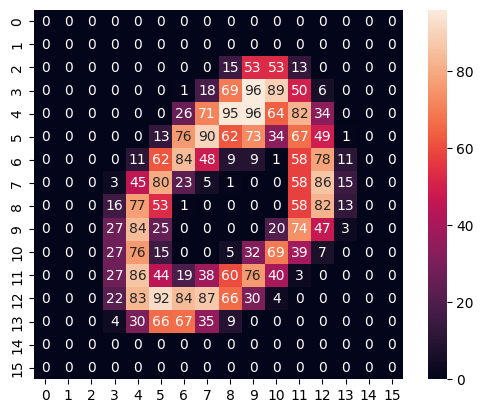

2192
1956


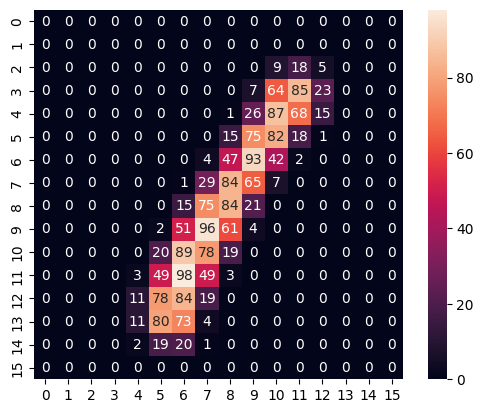

In [4]:
plt.imshow(scaled_pixels0[0].squeeze())
sns.heatmap(scaled_pixels0[0].squeeze(), annot=True)

print(sum(sum(scaled_pixels0[0])))

s = 0
for i in range(len(scaled_pixels0)):
    s += sum(sum((scaled_pixels0[i])))
s = int(s / len(scaled_pixels0))
print(s)
plt.show()

plt.imshow(scaled_pixels1[0].squeeze())
sns.heatmap(scaled_pixels1[0].squeeze(), annot=True)

print(sum(sum(scaled_pixels1[0])))

s = 0
for i in range(len(scaled_pixels1)):
    s += sum(sum((scaled_pixels1[i])))
s = int(s / len(scaled_pixels1))
print(s)
plt.show()

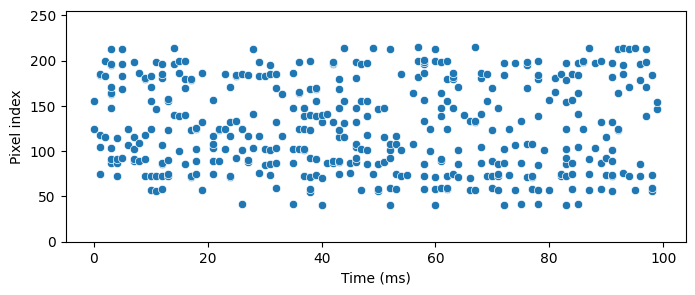

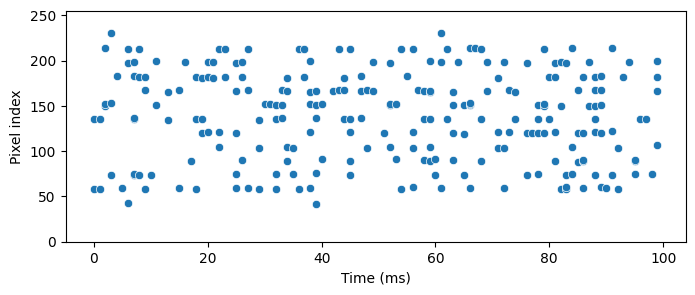

In [5]:
T = 100
dt = 1e-3
tensor_pixels0 = torch.tensor(scaled_pixels0).repeat(T, 1, 1, 1).transpose(0, 1)
tensor_pixels0 = torch.bernoulli(tensor_pixels0 * dt)
t, idx = torch.where(tensor_pixels0[0].view(T, -1))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
# plt.plot(t, idx, '|')
sns.scatterplot(x=t, y=idx, ax=ax)
ax.set(xlabel="Time (ms)", ylabel="Pixel index", ylim=[0, 255])
plt.show()

tensor_pixels1 = torch.tensor(scaled_pixels1).repeat(T, 1, 1, 1).transpose(0, 1)
tensor_pixels1 = torch.bernoulli(tensor_pixels1 * dt)
t, idx = torch.where(tensor_pixels1[0].view(T, -1))

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
# plt.plot(t, idx, '|')
sns.scatterplot(x=t, y=idx, ax=ax)
ax.set(xlabel="Time (ms)", ylabel="Pixel index", ylim=[0, 255])
plt.show()

In [6]:
from torch.utils.data import TensorDataset

tensor_pixels = torch.concat([tensor_pixels0, tensor_pixels1], dim=0)
tensor_labels = torch.concat(
    [torch.zeros(tensor_pixels0.shape[0]), torch.ones(tensor_pixels1.shape[0])], dim=0
)
dataset = TensorDataset(tensor_pixels, tensor_labels)

In [7]:
scaled_pixels0 = np.load(os.path.join("./data/test", "MNIST0.npy"))
scaled_pixels1 = np.load(os.path.join("./data/test", "MNIST1.npy"))

In [8]:
T = 100
dt = 1e-3
tensor_pixels0 = torch.tensor(scaled_pixels0).repeat(T, 1, 1, 1).transpose(0, 1)
tensor_pixels0 = torch.bernoulli(tensor_pixels0 * dt)
t, idx = torch.where(tensor_pixels0[0].view(T, -1))

tensor_pixels1 = torch.tensor(scaled_pixels1).repeat(T, 1, 1, 1).transpose(0, 1)
tensor_pixels1 = torch.bernoulli(tensor_pixels1 * dt)
t, idx = torch.where(tensor_pixels1[0].view(T, -1))

tensor_pixels = torch.concat([tensor_pixels0, tensor_pixels1], dim=0)
tensor_labels = torch.concat(
    [torch.zeros(tensor_pixels0.shape[0]), torch.ones(tensor_pixels1.shape[0])], dim=0
)
dataset_test = TensorDataset(tensor_pixels, tensor_labels)

4005
4541


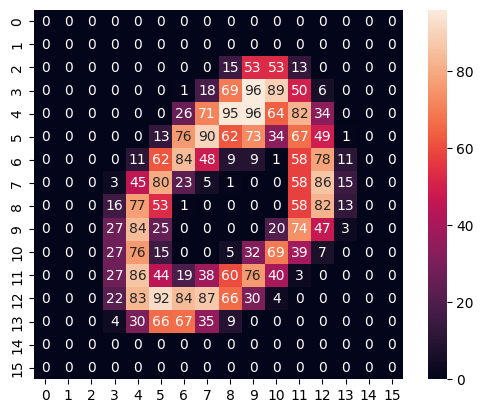

In [9]:
min_val, max_val, diff = 0, 6, 1
plt.imshow(scaled_pixels0[0].squeeze())
sns.heatmap(scaled_pixels0[0].squeeze(), annot=True)

print(sum(sum(scaled_pixels0[0])))

s = 0
for i in range(len(scaled_pixels0)):
    s += sum(sum((scaled_pixels0[i])))
s = int(s / len(scaled_pixels0))
print(s)
plt.show()

In [20]:
import os
from tqdm import tqdm


def train(neuron, optimizer, epochs, dataset, logFile=None, plot=False):
    neuron.train()
    trainLoss = []
    trainAcc = []
    for epoch in range(epochs):
        accEpoch = []
        lossEpoch = []
        pbar = tqdm(enumerate(dataset), total=len(dataset))
        for idx, (X, label) in pbar:
            outAcum = 0.0
            IampaAcum = 0.0
            IgababAcum = 0.0
            state = None
            for t in range(X.shape[1]):
                out, state = neuron(X[:, t].view(-1, size**2), state)
                (_, Iampa, _, _, Igaba, _) = state
                IampaAcum = IampaAcum + Iampa
                IgababAcum = IgababAcum + Igaba
                outAcum += out
            IampaAcum = torch.nn.functional.softmax(IampaAcum, dim=1)
            IgababAcum = torch.nn.functional.softmax(IgababAcum, dim=1)
            errLoss = torch.nn.functional.cross_entropy(
                IampaAcum - IgababAcum, label.long()
            )

            # newWeights = torch.cat([neuron.W_ampa, neuron.W_gabab], dim=1)
            # regL1Loss = torch.sum(torch.abs((torch.round(newWeights) + newWeights).detach() - newWeights))
            # regL2Loss = torch.sum(((torch.round(newWeights) + newWeights).detach() - newWeights)**2)

            # regL1Loss = torch.round(torch.sum(torch.abs(newWeights)))
            # regL2Loss = torch.round(torch.sum((newWeights)**2))

            # regL1Loss = torch.relu(torch.sum(torch.abs(torch.round(newWeights))) - 50)

            # loss = errLoss + 1/outAcum.sum(dim=-1).mean() + 0.01*regL1Loss #+ 10*regL1Loss + 10*regL2Loss#+ 0*regL1Loss + 0.0*regL2Loss
            loss = errLoss  # + 0.001*regL2Loss#+ 10*regL1Loss + 10*regL2Loss#+ 0*regL1Loss + 0.0*regL2Loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                acc = (torch.argmax(outAcum, dim=1) == label).cpu().float().mean()
                accEpoch.append(acc)
                lossEpoch.append(loss.item())

                neuron.add_mismatch("Iw_ampa", 0.1)
                neuron.add_mismatch("Iw_gabab", 0.1)

                if logFile is not None:
                    np.save(
                        os.path.join(
                            logFile, "weights", f"ampa{epoch*len(dataset)+idx+1}"
                        ),
                        neuron.W_ampa.data.numpy(),
                    )
                    np.save(
                        os.path.join(
                            logFile, "weights", f"gabab{epoch*len(dataset)+idx+1}"
                        ),
                        neuron.W_gabab.data.numpy(),
                    )
                    np.save(
                        os.path.join(
                            logFile, "gradients", f"ampa{epoch*len(dataset)+idx+1}"
                        ),
                        neuron.W_ampa.grad.numpy(),
                    )
                    np.save(
                        os.path.join(
                            logFile, "gradients", f"gabab{epoch*len(dataset)+idx+1}"
                        ),
                        neuron.W_gabab.grad.numpy(),
                    )

            pbar.set_postfix_str(
                f"Mean loss: {np.mean(lossEpoch):.3f}, ACC: {np.mean(accEpoch):.3f}"
            )
        with torch.no_grad():
            # newWeights = torch.nn.functional.softmax(torch.cat([neuron.W_ampa, neuron.W_gabab], dim=1), dim=1)*64
            newWeights = torch.cat([neuron.W_ampa, neuron.W_gabab], dim=1)
            newWeights = (
                40 * newWeights / newWeights.sum(dim=1).repeat(newWeights.shape[1], 1).T
            )
            neuron.W_ampa.data = newWeights[:, : newWeights.shape[1] // 2]
            neuron.W_gabab.data = newWeights[:, newWeights.shape[1] // 2 :]

        trainLoss.append(np.mean(lossEpoch))
        trainAcc.append(np.mean(accEpoch))

    if plot:
        fig, ax = plt.subplots()
        ax1 = ax
        ax2 = plt.twinx(ax)
        ax1.plot(trainLoss)
        ax2.plot(trainAcc)
        plt.show()


@torch.no_grad()
def test(neuron, dataset):
    neuron.eval()
    totalAcc = []
    neuron.add_mismatch(0.1)
    for X, label in tqdm(dataset):
        state = None
        totalImem = []
        totalIampa = []
        totalIgabab = []
        totalVmem = []
        outAcum = 0.0
        for t in range(X.shape[1]):
            out, state = neuron(X[:, t].view(-1, size**2), state)
            outAcum = outAcum + out
            (Imem, Iampa, _, _, Igabab, _) = state
            totalImem.append(Imem.numpy())
            totalIampa.append(Iampa.numpy())
            totalIgabab.append(Igabab.numpy())
            totalVmem.append(neuron.I2V(Imem).numpy())
        acc = (torch.argmax(outAcum, dim=1) == label).cpu().float().mean().item()
        totalAcc.append(acc)
    return (
        totalImem,
        np.stack(totalVmem),
        np.stack(totalIampa),
        np.stack(totalIgabab),
        np.array(totalAcc),
        label,
    )

In [21]:
neuron = DPINeuron(
    size**2,
    2,
    Itau_mem=1.8e-12,
    Igain_mem=75e-12,
    Ith=1.2,
    Idc=240e-12,
    refP=0.0,
    Ipfb_th=225e-12,
    Ipfb_norm=1.0e9,
    Itau_ampa=4e-12,
    Igain_ampa=10e-12,
    Iw_ampa=420e-12,
    Itau_gabab=4e-12,
    Igain_gabab=10e-12,
    Iw_gabab=420e-12,
    dt=1e-3,
    train_Igain_mem=False,
    train_Itau_mem=False,
    train_ampa=True,
    train_gabab=True,
)
torch.nn.init.uniform_(neuron.W_ampa, a=0.0, b=1)
torch.nn.init.uniform_(neuron.W_gabab, a=0.0, b=1)
optimizer = torch.optim.SGD(neuron.parameters(), lr=1e-3)
optimizer.register_step_post_hook(neuron.UpdateParams)
# train(neuron, optimizer, 2, train_dataloader)
dl = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)
dl_test = torch.utils.data.DataLoader(dataset_test, batch_size=128, shuffle=True)

In [22]:
X, label = next(iter(dl))
outAcum = 0.0
IampaAcum = 0.0
IgababAcum = 0.0
state = None
neuron.train()
totalIampa = []
totalIgabab = []
for t in range(X.shape[1]):
    out, state = neuron(X[:, t].view(-1, size**2), state)
    (_, Iampa, _, _, Igabab, _) = state
    totalIampa.append(Iampa.detach().numpy())
    totalIgabab.append(Igabab.detach().numpy())
    IampaAcum = IampaAcum + Iampa
    IgababAcum = IgababAcum + Igabab
    outAcum += out
IampaAcum.retain_grad()
IgababAcum.retain_grad()
totalIampa = np.stack(totalIampa)
totalIgabab = np.stack(totalIgabab)
IampaAcumSoftmax = torch.nn.functional.softmax(IampaAcum, dim=1)
IgababAcumSoftmax = torch.nn.functional.softmax(IgababAcum, dim=1)
errLoss = torch.nn.functional.cross_entropy(IampaAcum - IgababAcum, label.long())

# newWeights = torch.cat([neuron.W_ampa, neuron.W_gabab], dim=1)
# regL1Loss = torch.sum(torch.abs((torch.round(newWeights) + newWeights).detach() - newWeights))
# regL2Loss = torch.sum(((torch.round(newWeights) + newWeights).detach() - newWeights)**2)

# regL1Loss = torch.sum(torch.abs(newWeights))
# regL2Loss = torch.sum((newWeights)**2)

loss = errLoss  # + 0.01*regL1Loss #+ 50*regL2Loss
optimizer.zero_grad()
loss.backward()
# optimizer.step()

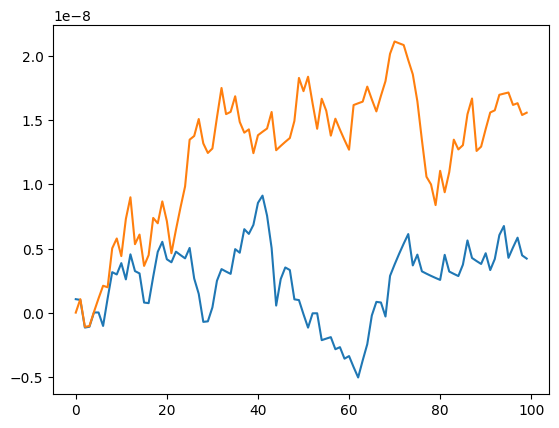

In [23]:
plt.plot(totalIampa[:, 0] - totalIgabab[:, 0])

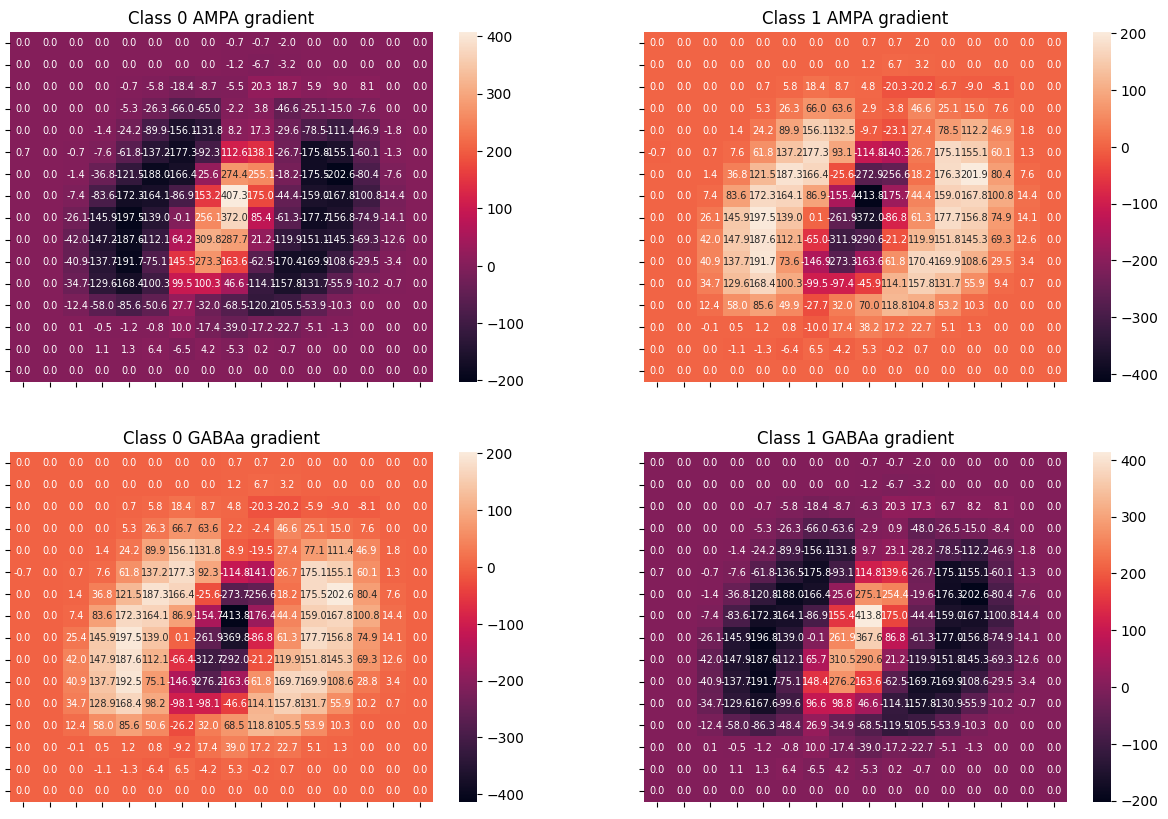

In [24]:
with torch.no_grad():
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    htm1 = sns.heatmap(
        neuron.W_ampa.grad[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_ampa.grad[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 AMPA gradient")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 AMPA gradient")

    htm1 = sns.heatmap(
        neuron.W_gabab.grad[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_gabab.grad[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 GABAa gradient")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 GABAa gradient")

    plt.show()

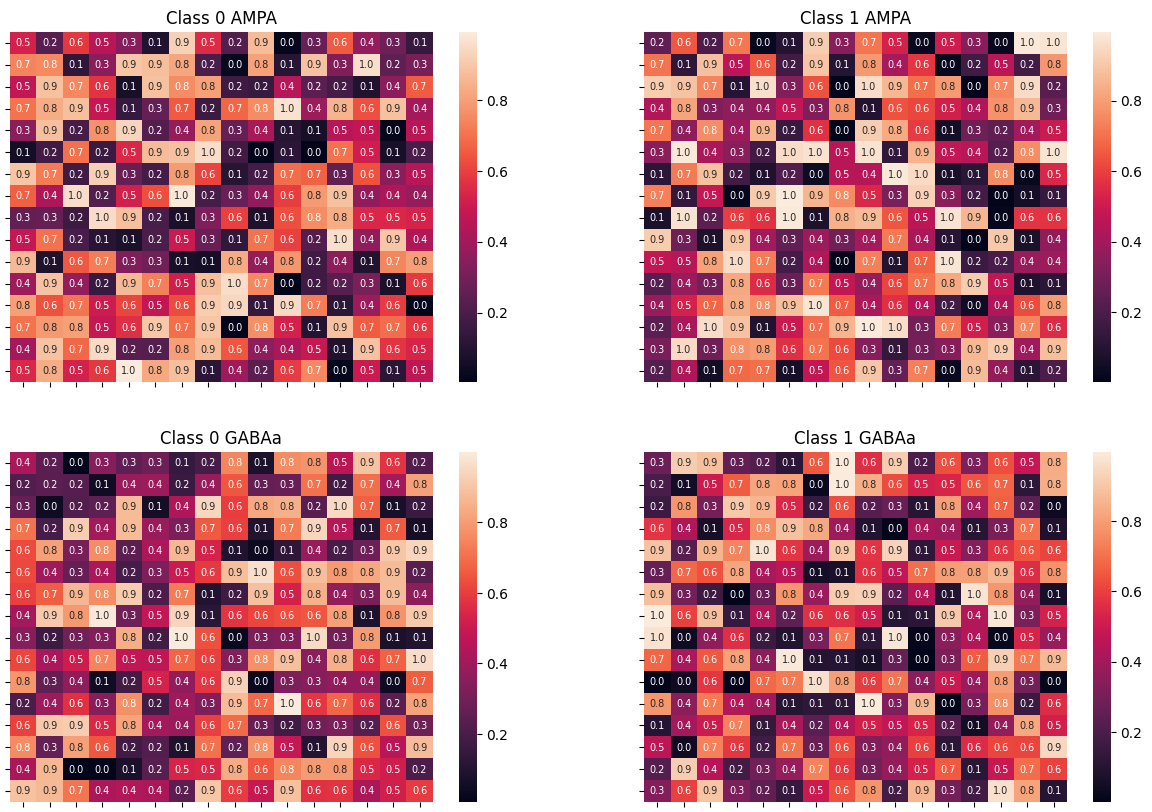

In [25]:
with torch.no_grad():
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    htm1 = sns.heatmap(
        neuron.W_ampa[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_ampa[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 AMPA")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 AMPA")

    htm1 = sns.heatmap(
        neuron.W_gabab[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_gabab[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 GABAa")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 GABAa")

    plt.show()

In [26]:
train(neuron, optimizer, 1, dl, logFile="./log")

100%|██████████| 99/99 [00:15<00:00,  6.34it/s, Mean loss: 0.693, ACC: 0.964]


In [17]:
newWeights = torch.cat([neuron.W_ampa, neuron.W_gabab], dim=1)
torch.round(newWeights).sum(dim=1, keepdim=True)

tensor([[31.],
        [30.]], grad_fn=<SumBackward1>)

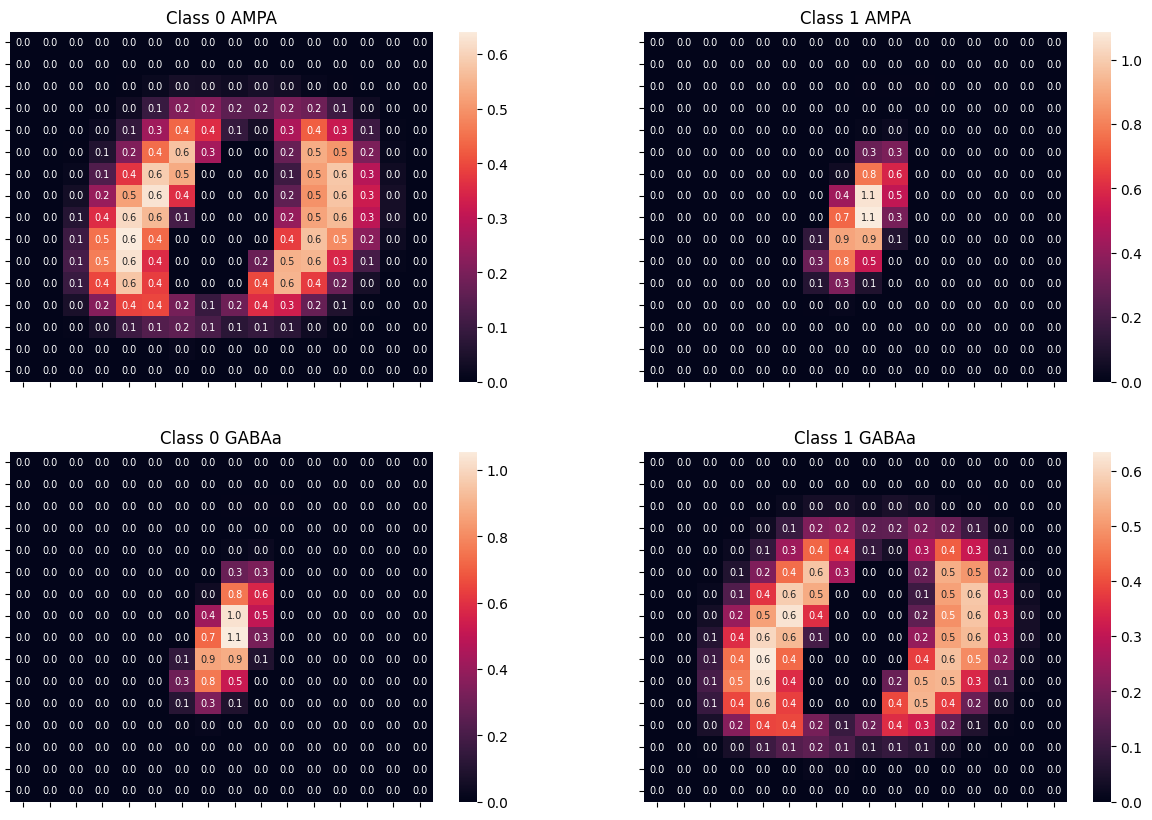

In [18]:
with torch.no_grad():
    # np.save(os.path.join('/home/ferqui/Work/dynapse/Experiments/mnist/weights', f'ampa{198}'), neuron.W_ampa.data.numpy())
    # np.save(os.path.join('/home/ferqui/Work/dynapse/Experiments/mnist/weights', f'gabab{198}'), neuron.W_gabab.data.numpy())

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    htm1 = sns.heatmap(
        neuron.W_ampa[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_ampa[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 AMPA")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 AMPA")

    htm1 = sns.heatmap(
        neuron.W_gabab[0, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 0],
    )
    htm2 = sns.heatmap(
        neuron.W_gabab[1, :].reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 GABAa")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 GABAa")

    # plt.savefig('/home/ferqui/Work/dynapse/231010/mnist/figures/InitialWeights.pdf', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()

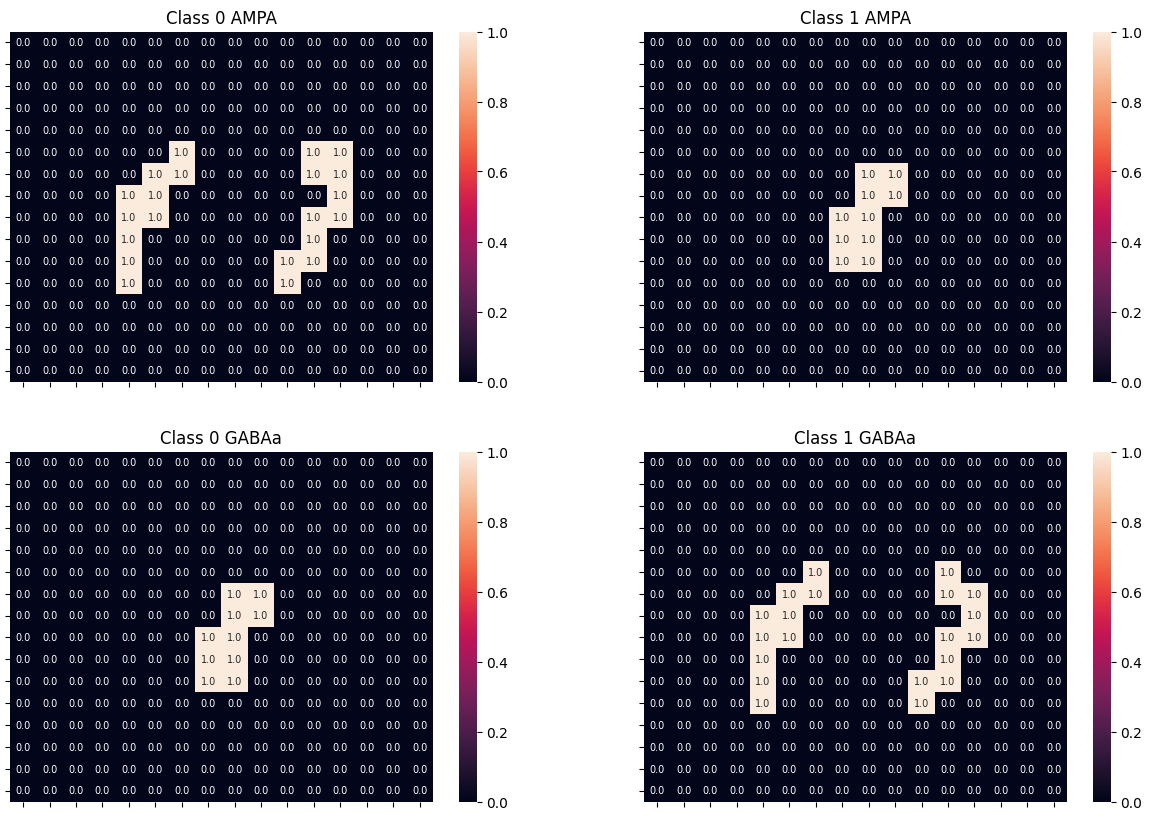

In [19]:
with torch.no_grad():
    # np.save(os.path.join('/home/ferqui/Work/dynapse/Experiments/mnist/weights', f'ampa{198}'), neuron.W_ampa.data.numpy())
    # np.save(os.path.join('/home/ferqui/Work/dynapse/Experiments/mnist/weights', f'gabab{198}'), neuron.W_gabab.data.numpy())

    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    htm1 = sns.heatmap(
        np.round(neuron.W_ampa[0, :]).reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 0],
    )
    htm2 = sns.heatmap(
        np.round(neuron.W_ampa[1, :]).reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[0, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 AMPA")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 AMPA")

    htm1 = sns.heatmap(
        np.round(neuron.W_gabab[0, :]).reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 0],
    )
    htm2 = sns.heatmap(
        np.round(neuron.W_gabab[1, :]).reshape(size, size),
        annot=True,
        fmt=".1f",
        annot_kws={"size": 7},
        ax=axs[1, 1],
    )
    htm1.set(xticklabels=[])
    htm1.set(yticklabels=[])
    htm1.set(title="Class 0 GABAa")

    htm2.set(xticklabels=[])
    htm2.set(yticklabels=[])
    htm2.set(title="Class 1 GABAa")

    # plt.savefig('/home/ferqui/Work/dynapse/231010/mnist/figures/InitialWeights.pdf', bbox_inches='tight', transparent=True, dpi=300)
    plt.show()